# Phase 3 - Notebook 11: Hybrid Pipeline Demo

End-to-end demonstration of OCR/text input -> clause modeling -> interface evidence -> Bayesian inference.

This notebook runs on local project artifacts and prints a deterministic inference trace for selected CUAD contracts.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Ensure project root is importable when notebook runs from notebooks/Phase_3.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Phase_3":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase3.bayesian.bootstrap import ensure_seed_model
from src.phase3.bayesian.inference import run_inference
from src.phase3.hybrid_pipeline import AgastyaHybridPipeline

/Users/subhammahapatra/Downloads/agastya/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_path = ensure_seed_model(str(PROJECT_ROOT / "results" / "phase3" / "bayesian_network.pkl"))
pipeline = AgastyaHybridPipeline(
    bn_model_path=model_path,
    bert_checkpoint_path=str(PROJECT_ROOT / "phase2_results" / "legal_bert_phase2.pt"),
)

test_csv = PROJECT_ROOT / "data" / "processed" / "test.csv"
sample_df = pd.read_csv(test_csv)
contracts = sample_df.groupby("filename", as_index=False).first().head(5)
contracts[["filename", "text", "label"]].head()

,filename,text,label
0,ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...,['JOINT VENTURE AGREEMENT'],Document Name
1,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...",['CONSULTING AGREEMENT'],Document Name
2,AgapeAtpCorp_20191202_10-KA_EX-10.1_11911128_E...,['ODM SUPPLY AGREEMENT'],Document Name
3,BIOAMBERINC_04_10_2013-EX-10.34-DEVELOPMENT AG...,['First Amendment'],Document Name
4,"BLUEHILLSBANCORP,INC_05_20_2014-EX-1.1-AGENCY ...",['AGENCY AGREEMENT'],Document Name


In [3]:
results = []
for _, row in contracts.iterrows():
    out = pipeline.predict(str(row["text"]))
    results.append(
        {
            "filename": row["filename"],
            "risk_level": out["risk_level"],
            "p_low": out["risk_probabilities"].get("Low", 0.0),
            "p_medium": out["risk_probabilities"].get("Medium", 0.0),
            "p_high": out["risk_probabilities"].get("High", 0.0),
            "conflict_signal": out["conflict_signal"],
            "hard_evidence": out["clause_evidence"],
            "virtual_evidence": out["virtual_evidence"],
        }
    )

results_df = pd.DataFrame(results)
results_df[["filename", "risk_level", "p_low", "p_medium", "p_high", "conflict_signal"]]

,filename,risk_level,p_low,p_medium,p_high,conflict_signal
0,ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...,Low,0.748092,0.251908,0.0,0.5
1,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...",Low,0.748092,0.251908,0.0,0.5
2,AgapeAtpCorp_20191202_10-KA_EX-10.1_11911128_E...,Low,0.748092,0.251908,0.0,0.5
3,BIOAMBERINC_04_10_2013-EX-10.34-DEVELOPMENT AG...,Low,0.748092,0.251908,0.0,0.5
4,"BLUEHILLSBANCORP,INC_05_20_2014-EX-1.1-AGENCY ...",Low,0.748092,0.251908,0.0,0.5


In [4]:
trace_contract = contracts.iloc[0]
trace_out = pipeline.predict(str(trace_contract["text"]))
hard_evidence = trace_out["clause_evidence"]

prior = run_inference(pipeline.bn, evidence={})
posterior = run_inference(pipeline.bn, evidence=hard_evidence)

print("Contract:", trace_contract["filename"])
print("Prior P(Contract_Risk_Level):", prior["probabilities"])
print("Posterior P(Contract_Risk_Level | evidence):", posterior["probabilities"])
print("Hard evidence:", hard_evidence)
print("Virtual evidence:", trace_out["virtual_evidence"])

Contract: ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-EX-10.13-JOINT VENTURE AGREEMENT.PDF
Prior P(Contract_Risk_Level): {'High': 0.5877969742124373, 'Low': 0.19443661825222686, 'Medium': 0.21776640753533588}
Posterior P(Contract_Risk_Level | evidence): {'High': 0.0, 'Low': 0.7480916030534351, 'Medium': 0.2519083969465649}
Hard evidence: {'Has_Payment_Clause': 'Absent', 'Has_Termination_Clause': 'Absent', 'Has_Liability_Clause': 'Absent', 'Has_Confidentiality_Clause': 'Absent', 'Has_Dispute_Resolution_Clause': 'Absent'}
Virtual evidence: {}


/var/folders/y2/hmwq0f3579d1ld3k4y_7js1m0000gn/T/ipykernel_72387/4420701.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


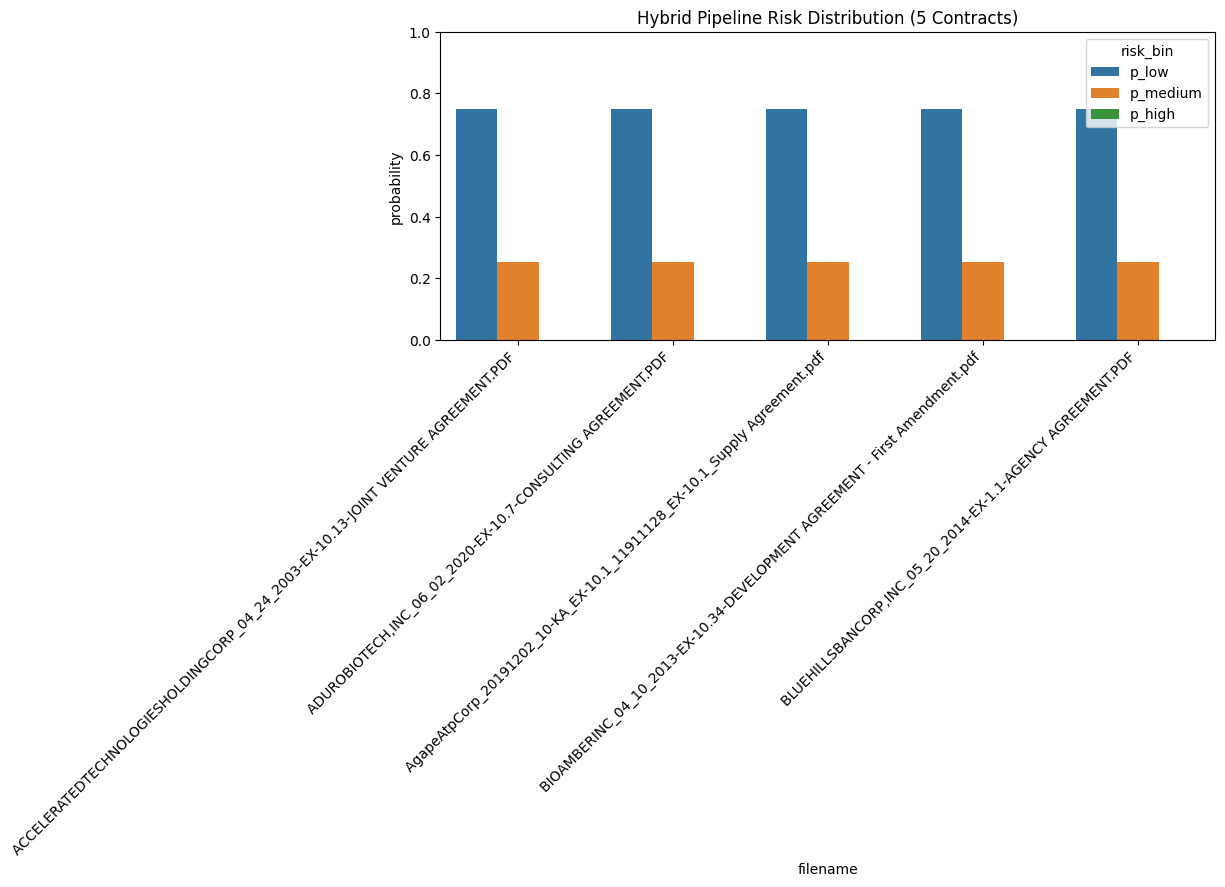

In [5]:
plot_df = results_df.melt(
    id_vars=["filename"],
    value_vars=["p_low", "p_medium", "p_high"],
    var_name="risk_bin",
    value_name="probability",
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="filename", y="probability", hue="risk_bin")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Hybrid Pipeline Risk Distribution (5 Contracts)")
plt.tight_layout()
plt.show()

In [6]:
reports_dir = PROJECT_ROOT / "reports" / "phase3"
reports_dir.mkdir(parents=True, exist_ok=True)
out_path = reports_dir / "hybrid_demo_results.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: /Users/subhammahapatra/Downloads/agastya/reports/phase3/hybrid_demo_results.csv
